# Subducting plate — black-and-white schematic

A 2D cross-section for the talk's setup slide. **Schematic, not to scale** — the vertical axis is heavily exaggerated so the trench depression is the dominant feature.

**Elements**

- *Surface* (solid line) — flat at the ridge, gentle √age cooling subsidence, then bends down through an **elastic-flexure** depression at the trench (the visible dip filled with water), then continues as the slab.
- *Isotherm* (dashed line) — meets the surface at the ridge, thickens as √age, parallels the slab.
- *Sea level* and *trench-axis depth* — light reference lines at z = 0 and z = z_trench.
- *Water* — light grey fill between sea level and the plate surface, only in the pre-trench region (the overriding plate is omitted).

Saves PNG to `figures/`. Copy to `../presentation/figures/` when ready.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 0.8,
    "axes.edgecolor": "black",
})

### Geometry parameters

All in km. Tweak `W_t` (trench depression magnitude) and `alpha` (flexural wavelength) to control how dramatic the trench is.

In [12]:
L         = 400.0     # ridge → trench distance (compressed)
L_slab    = 75.0      # post-bend slab length (short — exits the figure)
S0        = 5.0       # regional cooling subsidence at trench (small)
W_t       = 5.0      # trench depression below regional (the focus)
alpha     = 65.0      # flexural wavelength scale
H_plate   = 35.0      # plate thickness at trench
dip_deg   = 40.0      # slab dip
R_top     = 80.0      # outer (top-surface) bend radius at the trench

dip = np.deg2rad(dip_deg)

# --- Pre-trench surface: cooling subsidence + elastic flexure ---------------
xp = np.linspace(0, L, 600)
z_regional = S0 * np.sqrt(xp / L)
xi = (L - xp) / alpha
z_flexure  = W_t * np.exp(-xi) * np.cos(xi)
z_top_pre  = z_regional + z_flexure
z_iso_pre  = z_top_pre + H_plate * np.sqrt(xp / L)

# --- Bend at the trench (smooth arc into fixed slab dip) --------------------
dz_dx_at_L = W_t / alpha + 0.5 * S0 / L
theta_init = np.arctan(dz_dx_at_L)
bend_angle = dip - theta_init

xC = L - R_top * np.sin(theta_init)
zC = z_top_pre[-1] + R_top * np.cos(theta_init)
R_bot = R_top - H_plate

delta = np.linspace(0, bend_angle, 200)
x_bend_top = xC + R_top * np.sin(theta_init + delta)
z_bend_top = zC - R_top * np.cos(theta_init + delta)
x_bend_iso = xC + R_bot * np.sin(theta_init + delta)
z_bend_iso = zC - R_bot * np.cos(theta_init + delta)

# --- Slab continues at fixed dip --------------------------------------------
ts = np.linspace(0, L_slab, 150)
x_slab_top = x_bend_top[-1] + ts * np.cos(dip)
z_slab_top = z_bend_top[-1] + ts * np.sin(dip)
x_slab_iso = x_bend_iso[-1] + ts * np.cos(dip)
z_slab_iso = z_bend_iso[-1] + ts * np.sin(dip)

x_top = np.concatenate([xp, x_bend_top, x_slab_top])
z_top = np.concatenate([z_top_pre, z_bend_top, z_slab_top])
x_iso = np.concatenate([xp, x_bend_iso, x_slab_iso])
z_iso = np.concatenate([z_iso_pre, z_bend_iso, z_slab_iso])

z_trench_axis = float(z_top_pre[-1])

### Plot

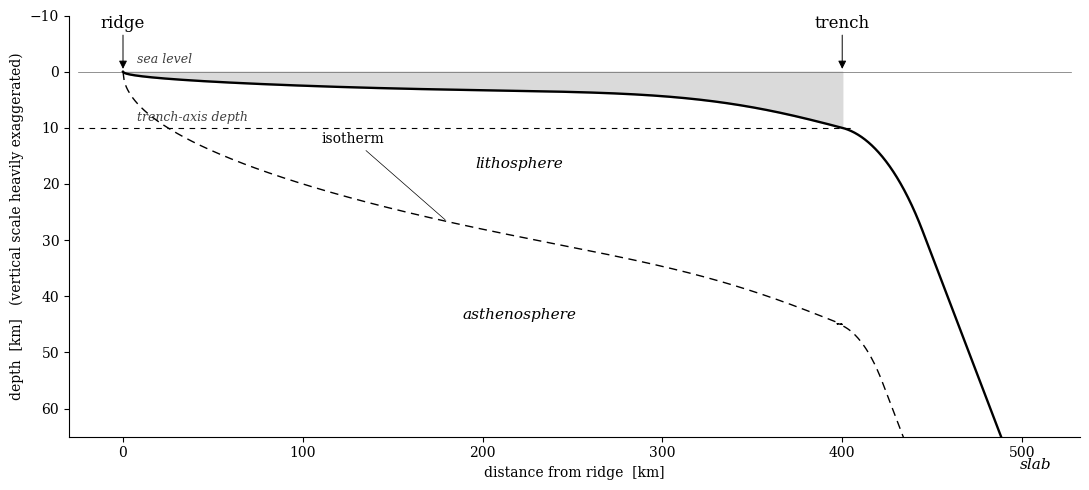

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))

# Water — only in the pre-trench region (out to the trench axis)
mask = x_top <= L
ax.fill_between(x_top[mask], 0, z_top[mask], color="#dadada", zorder=1)

# Sea-level reference
ax.plot([-25, x_top.max() + 25], [0, 0], color="0.4", lw=0.5, zorder=2)
ax.text(L * 0.02, -1.0, "sea level", fontsize=9, ha="left", va="bottom",
        style="italic", color="0.25")

# Trench-axis horizontal reference (only across pre-trench region)
ax.plot([-25, L + 5], [z_trench_axis, z_trench_axis],
        color="k", ls="--", lw=0.8, dashes=(5, 5), zorder=2)
ax.text(L * 0.02, z_trench_axis - 0.6, "trench-axis depth",
        fontsize=9, ha="left", va="bottom", style="italic", color="0.25")

# Plate surface and isotherm
ax.plot(x_top, z_top, "k-", lw=1.7, zorder=4)
ax.plot(x_iso, z_iso, "k-", lw=1.0, dashes=(6, 4), zorder=4)

# Ridge & trench markers
for x_mark, label in [(0, "ridge"), (L, "trench")]:
    ax.annotate(label, xy=(x_mark, 0), xytext=(x_mark, -7),
                ha="center", va="bottom", fontsize=12,
                arrowprops=dict(arrowstyle="-|>", lw=0.7, color="k",
                                shrinkA=0, shrinkB=2))

# Region labels
mid = int(0.55 * len(xp))
ax.text(xp[mid], 0.5 * (z_top_pre[mid] + z_iso_pre[mid]),
        "lithosphere", fontsize=11, style="italic", ha="center", va="center")
ax.text(xp[mid], z_iso_pre[mid] + 14, "asthenosphere",
        fontsize=11, style="italic", ha="center", va="center")

slab_mid_idx = len(ts) // 2
slab_mid_x = x_slab_top[slab_mid_idx]
slab_mid_z = 0.5 * (z_slab_top[slab_mid_idx] + z_slab_iso[slab_mid_idx])
ax.text(slab_mid_x + 25, slab_mid_z + 4, "slab",
        fontsize=11, style="italic", ha="left", va="center")

iso_idx = int(0.45 * len(xp))
ax.annotate("isotherm",
            xy=(xp[iso_idx], z_iso_pre[iso_idx]),
            xytext=(xp[iso_idx] - 70, z_iso_pre[iso_idx] - 14),
            fontsize=10, ha="left",
            arrowprops=dict(arrowstyle="-", lw=0.5))

ax.invert_yaxis()
ax.set_xlim(-30, x_top.max() + 30)
ax.set_ylim(65, -10)
ax.set_xlabel("distance from ridge  [km]")
ax.set_ylabel("depth  [km]   (vertical scale heavily exaggerated)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / "subduction_schematic.png", bbox_inches="tight", dpi=220)
plt.show()